# **CODA (v2.0.0) Tutorial 1 — Quickstart & Reproducibility**

> **Goal of Tutorial 1**: Run a fully reproducible example with the **fewest possible steps**, then extend it to the full workflow (data preprocessing → global alignment → common domain identification → local alignment/LDDMM → spatial cross-correlation).

## **0. Environment setup & imports**

In [1]:
from CODA.Alignment import *
from CODA.Preprocessing import *
from CODA.RGBgenerator import *
from CODA.utils import *
from CODA.Cross_correlation import *
from CODA.Common_domain import *

D:\Anaconda\envs\CODA_test\lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## **1. Data loading & preparation**
* You can download all sample data required for this tutorial here: [Example data 1](<https://drive.google.com/drive/folders/1j2hN7IYEDTg8JPm2ECZNyn35-RsBIKxf?usp=drive_link>).

* After downloading, place the files in the same directory as this notebook (`Tutorial 1 (Full workflow).ipynb`).

### Data loading

In [2]:
data1_dir = '151673_data.csv' 
meta1_dir = '151673_meta.csv'

data2_dir = '151676_data.csv'  
meta2_dir = '151676_meta.csv' 

adata_73 = sc.read_csv(data1_dir).transpose()
meta_73 = pd.read_csv(meta1_dir)
adata_73.obs = meta_73
adata_73.obsm['spatial'] = meta_73[['ImageRow','ImageCol']].values

adata_76 = sc.read_csv(data2_dir).transpose()
meta_76 = pd.read_csv(meta2_dir)
adata_76.obs = meta_76
adata_76.obsm['spatial'] = meta_76[['ImageRow','ImageCol']].values

### Coordinate normalization & rotation perturbation
We normalize per-axis coordinates to a unified scale (`normalize_spatial(..., per_axis=True)`) and introduce a **180° rotation perturbation** on slice **151673** to emulate a strong angular mismatch.  
- `adata_73.obsm['spatial_rotated_180']`: rotated coordinates of 151673.  
- `adata_73/76.obsm['spatial_norm']`: per-axis normalized coordinates used as inputs to downstream alignment.


In [3]:
adata_73.obsm['spatial_rotated_180'], _ = normalized_rotation_perturbation(
    adata_73.obsm['spatial'], angle_degrees=180.0, per_axis=True
)
adata_73.obsm['spatial_norm'], _ = normalize_spatial(adata_73.obsm['spatial'], per_axis=True)  
adata_76.obsm['spatial_norm'], _ = normalize_spatial(adata_76.obsm['spatial'], per_axis=True)

### Pre-alignment overlay (two slices)
Scatter plot of the two slices **before alignment** using the prepared coordinates:  
- 151673 → `spatial_rotated_180` (blue)
- 151676 → `spatial_norm` (red)  

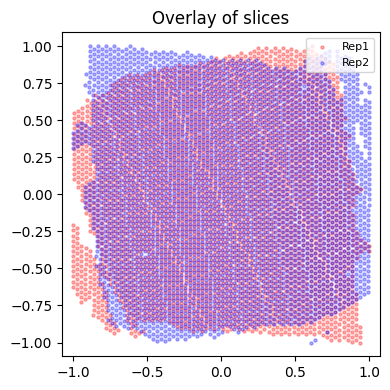

In [4]:
colors = ['red', 'blue']
labels = ['Rep1', 'Rep2']
adatas = [
    adata_76,
    adata_73
]
coord_keys = ['spatial_norm','spatial_rotated_180']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Overlay of slices")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

## **2. Data preprocessing**

### Key parameters 

- **integrate**: {"combat", "bbknn", "none"}
  - `"combat"` — per-gene batch correction; **modifies the expression matrix**.
  - `"bbknn"` — batch-balanced neighbor weighting/graph; **does not modify the expression matrix** (used for shared embedding).
  - `"none"` — no integration.

- **use_hvg**: `True` or `False`
  - `True` — select top highly variable genes (`n_top_genes`).
  - `False` — use all genes.

In [5]:
cfg = PreprocessConfig(
    integrate="bbknn",  
    use_hvg=True, n_top_genes=3000,
    normalize_target=1e4, log1p=True,
    scale_max_value=10.0, n_pcs=30,
    seed=0
)
sti = STIntegrator(cfg)

merged = sti.preprocess_and_integrate([adata_73, adata_76], batch_names=["73","76"])


### Embedding extraction
- `emb` — shared UMAP latent space for all cells/spots.
- `emb_rgb01` — first 3 components of `emb`, min–max scaled to **[0, 1]** for quick RGB previews.
- `n_components=3` sets the dimensionality (change as needed).

**Note:** The per-slice keys are exactly the strings in `batch_names`.  
With `batch_names=["73","76"]`, access them as:
```python
embedding_73 = split_emb["73"]
embedding_76 = split_emb["76"]
embedding_73_rgb = split_rgb["73"]
embedding_76_rgb = split_rgb["76"]

In [6]:
emb, emb_rgb01, split_emb, split_rgb = sti.embed(merged, n_components=3)

embedding_73 = split_emb["73"]
embedding_76 = split_emb["76"]
embedding_73_rgb = split_rgb["73"] 
embedding_76_rgb = split_rgb["76"]

### Visualizing in 2D / 3D
View the embedding by selecting component indices via `dims`:
- 2D: `plot_batches_in_embedding_2d(..., dims=(0, 1))`
- 3D: `plot_batches_in_embedding_3d(..., dims=(0, 1, 2))`

For embeddings with `d > 3`, choose any subset you want (e.g., `(1, 2)` or `(0, 2, 4)`).

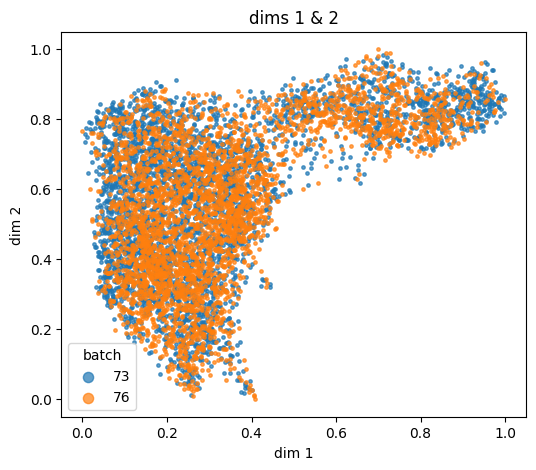

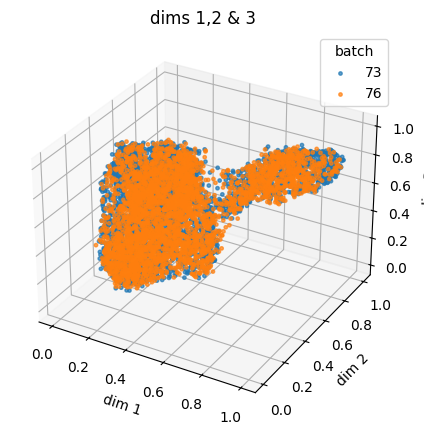

In [7]:
plot_batches_in_embedding_2d(merged, emb, batch_key="batch", dims=(0, 1), title="dims 1 & 2")
plot_batches_in_embedding_3d(merged, emb, batch_key="batch", dims=(0, 1, 2), title="dims 1,2 & 3")

### RGB preview on original slice coordinates
Visualize the first three latent dimensions as RGB on each **original slice**:

The strings "73" and "76" are exactly the **batch_names** keys for the two slices.

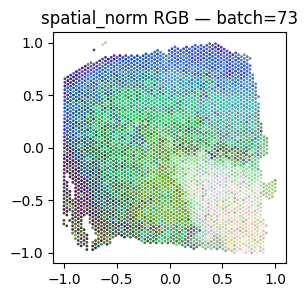

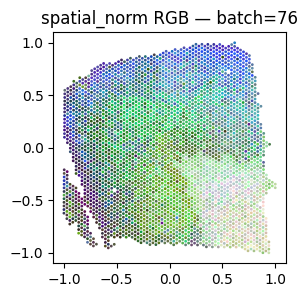

In [8]:
plot_slice_rgb(merged, embedding_73, "73", xy_key="spatial_norm") 
plot_slice_rgb(merged, embedding_76, "76", xy_key="spatial_norm") 

### Louvain clustering (merge → split back to slices)

- **Where it runs**: Run on the **merged** AnnData (`merged`).  
- **Outputs**: Labels are saved in `merged.obs["louvain"]` (set by `key_added="louvain"`).  
- **Back-propagate to slices**: Copy labels from `merged` to each per-slice object (`adata_73`, `adata_76`).  
  - The split uses the concat suffix from `ad.concat(..., index_unique='-')`, so obs names end with `-73` / `-76`.  
  - These suffixes correspond to your `batch_names=["73","76"]`. If `batch_names` change, the suffixes change accordingly.

In [9]:
sc.tl.louvain(merged, random_state=0, key_added="louvain", resolution=2)

adata_73.obs["louvain"] = merged.obs["louvain"][
    merged.obs_names.astype(str).str.endswith("-73")
].reset_index(drop=True).to_numpy()

adata_76.obs["louvain"] = merged.obs["louvain"][
    merged.obs_names.astype(str).str.endswith("-76")
].reset_index(drop=True).to_numpy()

## **3. Global alignment**

### Global alignment

- **`src_xy` / `dst_xy`**: the two spatial coordinate arrays to align; source → target.
- **`mode`**: one of `{"G1","G2","G2+"}`  
  - `G1` = rigid (rotation + translation)  
  - `G2` = similarity (uniform scale + rotation + translation)  
  - `G2+` = weak-affine (allows mild shear / anisotropic scale) — *used here*
- **`label_key="louvain"`**: the label column name in `.obs` used.  
  This column **must exist in both** `src_adata.obs` and `dst_adata.obs`.
  - You don’t have to use Louvain; any labels (including manual annotations) are fine.
- **Output**: aligned source coordinates are returned as `res["aligned"]` and stored in `adata_73.obsm["spatial_aligned"]`.

In [10]:
src_xy = adata_73.obsm['spatial_rotated_180']
dst_xy = adata_76.obsm['spatial_norm']

res = align_points(
    src_xy, dst_xy,
    src_feat=None, dst_feat=None,     
    mode="G2+", if_labeled=True,
    label_key="louvain",
    src_adata=adata_73,
    dst_adata=adata_76
)
adata_73.obsm['spatial_aligned'] = res['aligned']

### Global-alignment overlay (two slices)
Scatter plot of the two slices **After global alignment**.

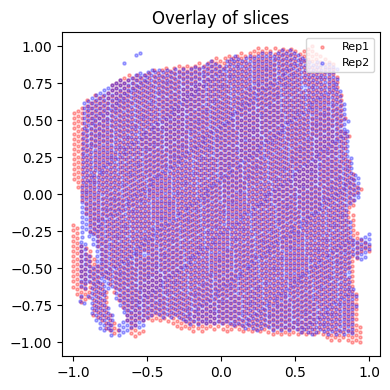

In [11]:
coord_keys = ['spatial_norm','spatial_aligned']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Overlay of slices")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

## **4. Integration of resolution (Generation of d-channel images)**

### Pick a joint canvas size
Use `suggest_joint_square_canvas_two(coords_73, coords_76)` to suggest an ** image size (`img_size`)** that suits **both** slices.  

In [12]:
coords_73 = np.asarray(adata_73.obsm["spatial"])
coords_76 = np.asarray(adata_76.obsm["spatial"])

suggest_joint_square_canvas_two(coords_73,coords_76)

(78, 78)

### Rasterizing the embedding and RGB preview

- **Canvas**: fix a joint resolution `img_size` so both slices rasterize onto the *same* grid.

- **d-channel images (for algorithms)**  
  - Input values: the full **d-dimensional embedding** (`embedding_73`, `embedding_76`).  
  - `create_rgb_image_with_mapping(coords, vals, img_size)` returns a dense image of shape **H×W×d** and a **mapping** from grid pixels to spot indices.  
  - **Interpolation** (`interpolate_zero_pixels`) fills only empty grid cells (zeros) with at least three non-zero grids around, leaving observed pixels unchanged. Use the **interpolated** d-channel images for downstream image-based steps (e.g., LDDMM).

- **RGB images (for visualization)**  
  - `embedding_to_rgb01` compresses the first 3 embedding components to **[0,1]**, then cast to `uint8` (0–255) for plotting.  

- **Keep the mappings** (`mapping_73`, `mapping_76`): they record how spots are placed on the grid and are useful for back-projecting results.

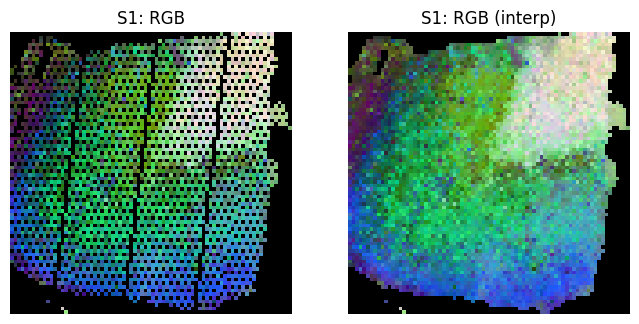

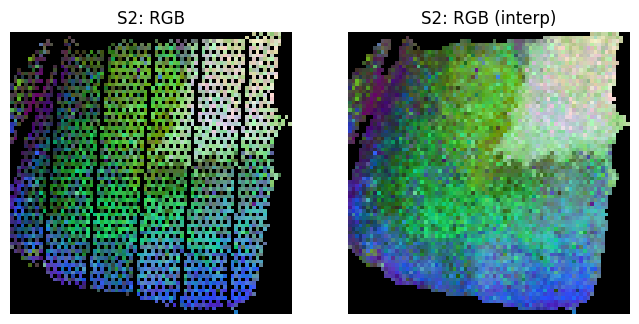

In [13]:
img_size = (78, 78)

# d-dimensional situation
# Slice1
vals_73   = embedding_73.astype(np.float32)       
img_73_d, mapping_73 = create_rgb_image_with_mapping(coords_73, vals_73, img_size=img_size)

# Slice2
vals_76   = embedding_76.astype(np.float32)         
img_76_d, mapping_76 = create_rgb_image_with_mapping(coords_76, vals_76, img_size=img_size)

# Interpolation
img_73_d_i = interpolate_zero_pixels(img_73_d, min_neighbors=3)
img_76_d_i = interpolate_zero_pixels(img_76_d, min_neighbors=3)

rgb73 = embedding_to_rgb01(embedding_73)      
rgb76 = embedding_to_rgb01(embedding_76)   

img_73_rgb, _ = create_rgb_image_with_mapping(coords_73, (rgb73*255).round().astype(np.uint8), img_size=img_size)
img_76_rgb, _ = create_rgb_image_with_mapping(coords_76, (rgb76*255).round().astype(np.uint8), img_size=img_size)

img_73_rgb_i = interpolate_zero_pixels(img_73_rgb, min_neighbors=3).astype(np.uint8)
img_76_rgb_i = interpolate_zero_pixels(img_76_rgb, min_neighbors=3).astype(np.uint8)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img_73_rgb);   plt.title("S1: RGB");        plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_73_rgb_i); plt.title("S1: RGB (interp)");plt.axis("off")
plt.show()

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img_76_rgb);   plt.title("S2: RGB");        plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_76_rgb_i); plt.title("S2: RGB (interp)");plt.axis("off")
plt.show()

## **5. Identification of common domain**

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 

extractor = CustomSPNet(max_num_keypoints=2048).eval().to(device) 
matcher = LightGlue(features="superpoint").eval().to(device)

In [15]:
image0 = torch.from_numpy(img_73_rgb_i/255).permute(2, 0, 1)
image0 = image0.to(torch.float32)
image1 = torch.from_numpy(img_76_rgb_i/255).permute(2, 0, 1)
image1 = image1.to(torch.float32)

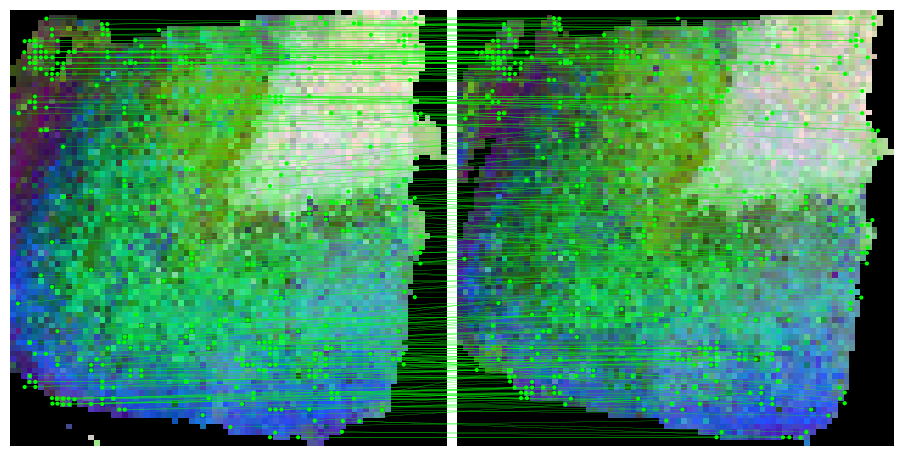

In [16]:
m_kpts0, m_kpts1,matches01 = extract_and_match_keypoints(
    image0, image1, extractor, matcher, device="cuda"
)

In [17]:
kpts0_np = m_kpts0.cpu().numpy()
kpts1_np = m_kpts1.cpu().numpy()

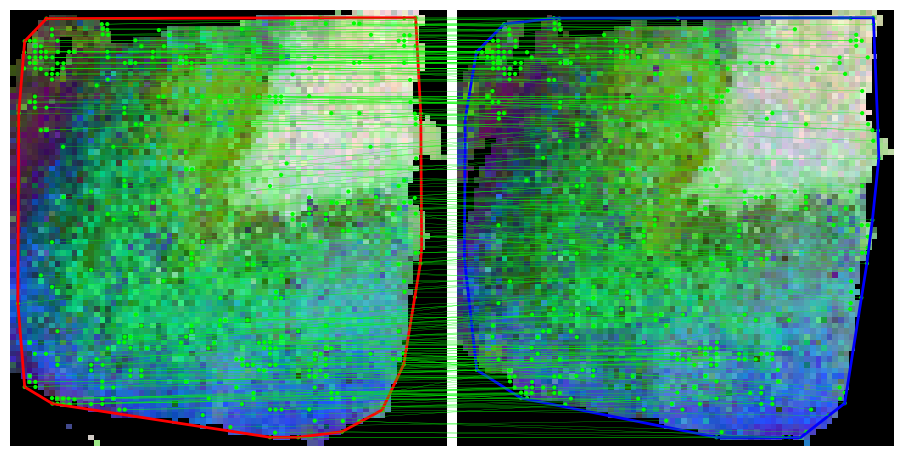

In [18]:
axes, bbox0, bbox1 = plot_match_regions(
    image0, image1, m_kpts0, m_kpts1, matches01, matches01["prune0"], matches01["prune1"], mode="convex"
)

hull0 = kpts0_np[ConvexHull(kpts0_np).vertices]
hull1 = kpts1_np[ConvexHull(kpts1_np).vertices]

poly0 = SPolygon(hull0)
poly1 = SPolygon(hull1)

cells_in_saline = extract_cells_from_polygon(poly0, mapping_73)
cells_in_rhy = extract_cells_from_polygon(poly1, mapping_76)
extracted_cells_rep1 = extract_cells_by_indices(adata_73, cells_in_saline)
extracted_cells_rep2 = extract_cells_by_indices(adata_76, cells_in_rhy)

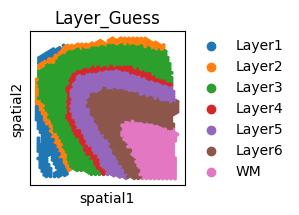

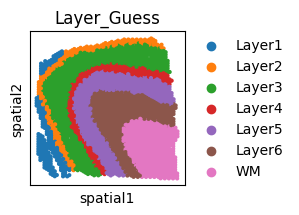

In [19]:
plt.rcParams['figure.figsize'] = [2,2]
sc.pl.embedding(extracted_cells_rep1, color='Layer_Guess', basis='spatial')
sc.pl.embedding(extracted_cells_rep2, color='Layer_Guess', basis='spatial')

## **6. Local alignment**
- **Inputs**: interpolated d-channel images `img_73_d_i` (source) and `img_76_d_i` (target).
- **Outputs**:
  - `aligned_image`: source warped into target space.
  - `Phi1[0]`: forward deformation (source → target); use with `direct_image_mapping_with_coords(...)`.

In [20]:
lddmm = LDDMM()
aligned_image, v_hat, energies, length, Phi0, Phi1, J0, J1 = lddmm.register(
    img_73_d_i, img_76_d_i, T=32, K=20, sigma=0.2, alpha=1, gamma=1, epsilon=0.001
)

iteration   0, energy 12868.15, thereof 0.00 regularization and 12868.15 intensity difference
iteration   1, energy 9234.12, thereof 35.65 regularization and 9198.46 intensity difference
iteration   2, energy 8115.93, thereof 44.46 regularization and 8071.48 intensity difference
iteration   3, energy 7471.46, thereof 55.67 regularization and 7415.79 intensity difference
iteration   4, energy 7133.63, thereof 61.32 regularization and 7072.32 intensity difference
iteration   5, energy 6704.08, thereof 70.98 regularization and 6633.10 intensity difference
iteration   6, energy 6521.31, thereof 74.96 regularization and 6446.35 intensity difference
iteration   7, energy 6131.90, thereof 82.91 regularization and 6048.99 intensity difference
iteration   8, energy 6049.22, thereof 86.28 regularization and 5962.94 intensity difference
iteration   9, energy 5721.91, thereof 92.94 regularization and 5628.98 intensity difference
iteration  10, energy 5699.70, thereof 96.13 regularization and 5603.

- **Canvas requirement**: keep **the same `img_size`** as chosen earlier (here `(78, 78)`) so the deformation field and mappings are consistent.

In [21]:
mapped_img_73, new_coords_73 = direct_image_mapping_with_coords(img_73_d,Phi1[0], mapping_73)
cell_positions_in_img_normal = find_cell_positions_in_image(coords_76, img_size=(78, 78))

### The results of local alignment

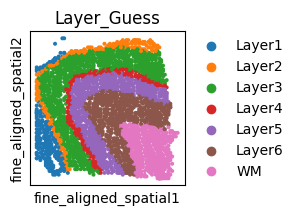

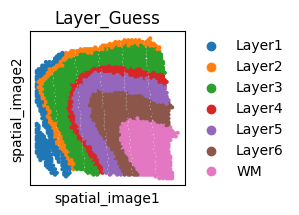

In [22]:
adata_73.obsm['fine_aligned_spatial'] = new_coords_73
adata_76.obsm['spatial_image'] = cell_positions_in_img_normal
sc.pl.embedding(adata_73, basis='fine_aligned_spatial', color='Layer_Guess')
sc.pl.embedding(adata_76, basis='spatial_image', color='Layer_Guess')

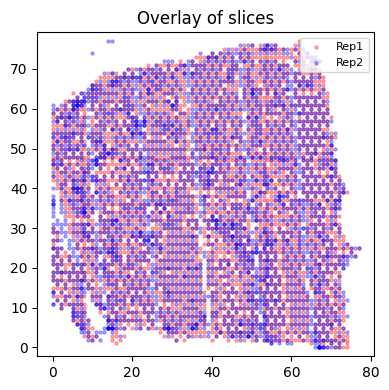

In [23]:
coord_keys = ['spatial_image','fine_aligned_spatial']

plt.figure(figsize=(4, 4))
for adata, key, color, label in zip(adatas, coord_keys, colors, labels):
    coords = adata.obsm[key]
    plt.scatter(coords[:, 0], coords[:, 1], s=5, alpha=0.3, label=label, color=color)

plt.title("Overlay of slices")
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.tight_layout()
plt.show()

## **7. Spatial gene analysis**

- Here we **subset to HVGs** for speed.

- You **can run with all genes**; expect significantly longer runtime (tens of thousands of genes typically **~30–60 min** depending on spots/hardware).

- HVG gives a **fast, reasonable approximation** for the tutorial; for comprehensive results (marker completeness, enrichment), consider using the **full gene set**.








In [24]:
adata_73_hvg = merged[merged.obs['batch'] =='73']
adata_76_hvg = merged[merged.obs['batch'] =='76']
adata_73_hvg.obsm['fine_aligned_spatial']=adata_73.obsm['fine_aligned_spatial']
adata_76_hvg.obsm['spatial_image'] = adata_76.obsm['spatial_image']

In [25]:
scc = SpatialCrossCorrelation(adata_73_hvg, adata_76_hvg,
                              coord_key_1='fine_aligned_spatial',
                              coord_key_2='spatial_image',
                              beta=1.0)

results = scc.compute_cross_correlation()

for gene, score in results[:10]:
    print(f"{gene}\t{score:.4f}")

MBP	0.7838
PLP1	0.6712
SCGB2A2	0.6326
MOBP	0.5847
GFAP	0.5707
TF	0.5454
CNP	0.5219
CRYAB	0.4795
MAG	0.4790
SCGB1D2	0.4598


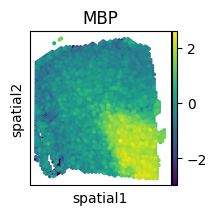

In [26]:
sc.pl.embedding(adata_73_hvg,basis='spatial',color='MBP')